# Useful Numerical Methods

This notebook gives a practical overview of some core tools used in mathematical modeling:
- Monte Carlo Sampling
- Euler Approximation
- ODE Integration with scipy.integrate.odeint

Each section focuses on method intuition and equations, with a minimal implementation.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

## 1) Monte Carlo Sampling

Monte Carlo methods are a broad class of computational algorithms that use random number sampling to obtain numerical results. The idea is to use randomness to solve complex deterministic problems with approximate solutions.

### Example: Pi estimation with random points

Generate random points uniformly in the square $[-L,L] \times [-L,L]$, where L is the half-side of the square (and radius of the contained circle).
Points that satisfy $x^2+y^2 \le L^2$ are inside the circle.
If $N$ is the total number of randomly generated points and $N_{in}$ is the number of points that fall inside the circle,

$$\frac{N_{in}}{N} \approx \frac{A_{circle}}{A_{square}} = \frac{\pi L^2}{(2L)^2} = \frac{\pi}{4},$$

so

$$\pi \approx 4\,\frac{N_{in}}{N}.$$

More sampling points improves the estimate, but convergence to the true value is gradual.

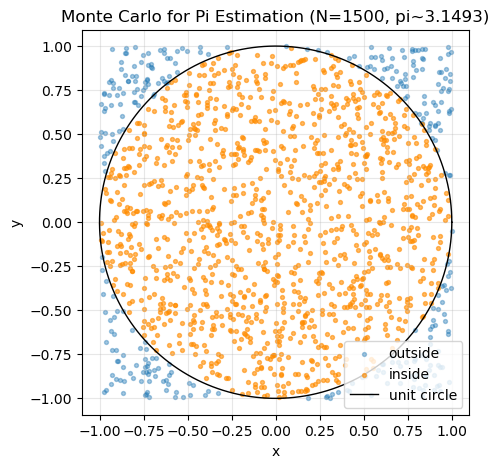

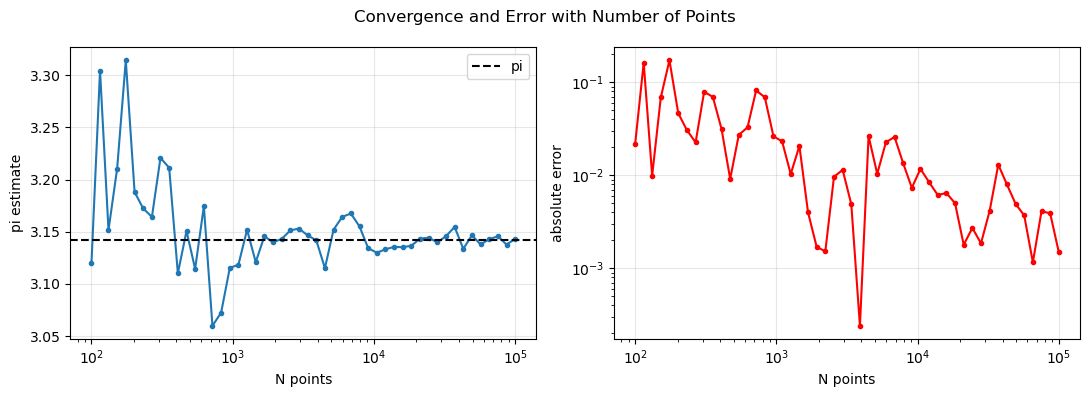

In [ ]:
def estimate_pi_monte_carlo(n_points, L = 1.0, seed = None, specific_points = False): # definition of the function with parameters
    rng = np.random.default_rng(seed) # create a numpy random number generator
    x = rng.uniform(-L, L, n_points) # generate n_points random x coordinates uniformly in the range [-L, L]
    y = rng.uniform(-L, L, n_points) # generate n_points random y coordinates uniformly in the range [-L, L]
    n_inside = (x**2 + y**2) <= L**2 # determine which points are inside the circle
    pi_estimate = 4.0 * np.mean(n_inside) # estimate pi using the defined formula

    if specific_points: # if specific_points is True
        return x, y, n_inside, pi_estimate # return all the points, their inside/outside status, and the estimate of pi
    return pi_estimate # return only the estimate of pi

# Visualization of the points
n_visual = 1500 # number of points to visualize
x_visual, y_visual, inside_visual, pi_visual = estimate_pi_monte_carlo(n_visual, L = 1.0, seed = 7, specific_points = True) # call the function and store the result in a variable for plotting

# Plotting the points and circle
theta = np.linspace(0, 2 * np.pi, 400) # create an array of angles to plot the unit circle
plt.figure(figsize = (5, 5)) # create a figure with specified size
plt.scatter(x_visual[~inside_visual], y_visual[~inside_visual], s = 8, alpha = 0.4, label = 'outside') # plot the points that are outside the circle
plt.scatter(x_visual[inside_visual], y_visual[inside_visual], s = 8, alpha = 0.6, color = 'darkorange', label = 'inside') # plot the points that are inside the circle
plt.plot(np.cos(theta), np.sin(theta), color = 'black', lw = 1, label = 'unit circle') # plot the circle using the cosine and sine of the angles
plt.xlabel('x') # label for the x-axis
plt.ylabel('y') # label for the y-axis
plt.title(f'Monte Carlo for Pi Estimation (N={n_visual}, pi~{pi_visual:.4f})') # title of the plot
plt.axis('equal') # set equal aspect ratio to ensure the circle looks circular
plt.grid(alpha = 0.3) # add a grid with transparency
plt.legend() # add a legend
plt.show() # display the plot

# Convergence to pi with number of generated points and error of the estimation
Ns = np.geomspace(100, 100000, 50).astype(int) # create an array of 50 values of N generated points logarithmically spaced between 100 and 100000
pi_estimates = [] # list to store pi estimates
errors = [] # list to store errors

for N in Ns: # loop over each value of N in Ns
    pi_estimate = estimate_pi_monte_carlo(N, seed = 42) # call the function to estimate pi for the current value of N
    error = np.abs(pi_estimate - np.pi) # calculate the absolute error of the estimation compared to pi
    pi_estimates.append(pi_estimate) # store the pi estimate in the list
    errors.append(error) # store the error in the list

# Plotting the convergence to pi and the error of the estimation
fig, axes = plt.subplots(1, 2, figsize = (11, 4)) # create a figure with 2 columns of subplots

axes[0].plot(Ns, pi_estimates, marker = 'o', ms = 3) # plot the estimated pi values against the number of points on the first subplot
axes[0].axhline(np.pi, ls = '--', color = 'black', label = 'pi') # add a horizontal line representing the true value of pi
axes[0].set_xscale('log') # set the x-axis to logarithmic scale
axes[0].set_xlabel('N points') # label for the x-axis
axes[0].set_ylabel('pi estimate') # label for the y-axis
axes[0].grid(alpha = 0.3) # add a grid with transparency
axes[0].legend() # add a legend

axes[1].plot(Ns, errors, marker = 'o', ms = 3, color = 'red') # plot the absolute error of the pi estimation against the number of points on the second subplot
axes[1].set_xscale('log') # set the x-axis to logarithmic scale
axes[1].set_yscale('log') # set the y-axis to logarithmic scale
axes[1].set_xlabel('N points') # label for the x-axis
axes[1].set_ylabel('absolute error') # label for the y-axis
axes[1].grid(alpha = 0.3) # add a grid with transparency

plt.suptitle('Convergence and Error with Number of Points') # title of the plot
plt.tight_layout() # adjust the layout to prevent overlap of subplots
plt.show() # display the plots, test

## 2) Euler Method

Euler is useful when a differential equation has no simple analytical solution and we need a numerical approximation on a discrete grid.

Given an initial value problem

$$\frac{dy}{dt}=f(t,y), \qquad y(t_0)=y_0,$$

Euler advances with step size $h$ using

$$y_{k+1}=y_k+h\,f(t_k,y_k).$$

### Numerical Approach

1. Choose step size $h$ and number of steps (or time grid).
2. Set initial condition $(t_0, y_0)$.
3. Compute the local slope $f(t_k,y_k)$.
4. Update to the next point with the Euler formula.
5. Repeat for all steps to build the approximate trajectory.

Interpretation: at each step, move forward using the tangent slope at the current point.

Practical notes:
- Smaller $h$ usually means better accuracy.
- Very large $h$ can produce inaccurate or unstable results.
- Euler is simple and fast, so it is useful for first prototypes and sanity checks.

Conventions often used in lectures:
$$y' = \frac{dy}{dx}, \qquad \dot{y} = \frac{dy}{dt}.$$

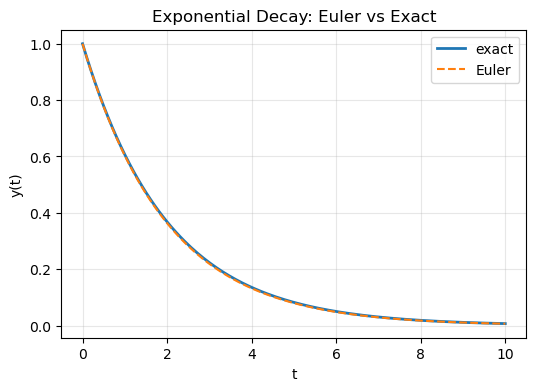

In [8]:
def euler_method(f, t_grid, y0, *args):
    y = np.zeros_like(t_grid, dtype=float)
    y[0] = y0
    for k in range(len(t_grid) - 1):
        h = t_grid[k + 1] - t_grid[k]
        y[k + 1] = y[k] + h * f(t_grid[k], y[k], *args)
    return y

def decay_rhs(t, y, tau):
    return -y / tau

tau = 2.0
t = np.linspace(0, 10, 200)
y_euler = euler_method(decay_rhs, t, 1.0, tau)
y_exact = np.exp(-t / tau)

plt.figure(figsize=(6, 4))
plt.plot(t, y_exact, label='exact', lw=2)
plt.plot(t, y_euler, '--', label='Euler')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Exponential Decay: Euler vs Exact')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 3) ODE Integration with odeint

`odeint` solves ordinary differential equations numerically, including systems of coupled equations.
Compared with fixed-step Euler, it is usually more robust because it adapts internal step sizes automatically.

You provide:
- a derivative function
- initial condition(s)
- a time grid
- model parameters

Typical workflow:
- define `func(y, t, *args)`
- set `y0` and `t`
- run `odeint(func, y0, t, args=(... ,))`

### Mass-Spring Example (as in lecture-style dynamics)

Second-order equation:

$$\ddot{x} = -\omega^2 x$$

Written as first-order system:

$$\dot{x}=v, \qquad \dot{v}=-\omega^2 x.$$

Analytical solution:

$$x(t)=A\cos(\omega t+\phi_0), \qquad v(t)=-\omega A\sin(\omega t+\phi_0),$$

with

$$A = \sqrt{x_0^2 + \frac{v_0^2}{\omega^2}}, \qquad \phi_0 = \arctan\left(-\frac{v_0}{\omega x_0}\right).$$

The code below compares the numerical and analytical solutions and also plots phase space $(x,v)$.

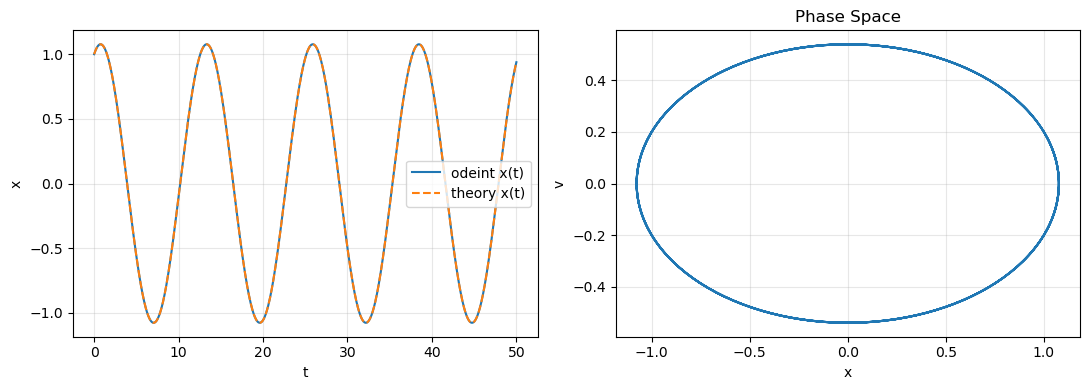

In [9]:
def mass_spring(y, t, w):
    x, v = y
    return [v, -(w**2) * x]

w = 0.5
x0, v0 = 1.0, 0.2
t = np.linspace(0, 50, 1000)
solution = odeint(mass_spring, [x0, v0], t, args=(w,))
x, v = solution.T

A = np.sqrt(x0**2 + (v0 / w)**2)
phi0 = np.arctan2(-v0 / w, x0)
x_theory = A * np.cos(w * t + phi0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t, x, label='odeint x(t)')
axes[0].plot(t, x_theory, ls='--', label='theory x(t)')
axes[0].set_xlabel('t')
axes[0].set_ylabel('x')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(x, v)
axes[1].set_xlabel('x')
axes[1].set_ylabel('v')
axes[1].set_title('Phase Space')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Method Selection Summary

- Monte Carlo: good for probabilistic, geometric, or sampling-based estimates.
- Euler: good for transparent step-by-step prototypes.
- odeint: better for final ODE simulations where stability and accuracy are important.

A practical strategy is to start with Euler for quick understanding, then move to odeint for stronger results.